# Complete Workflow for generating ATS input for Coweeta: Part 1 - Surface Meshing
 
This workflow demonstrates how to develop a simulation campaign for integrated hydrology using ATS. 
 
### Overview
 
Part 1 of this workflow focuses on creating a terrain-following surface mesh. It uses arbitrary polygonal shapes to generate computational elements that align with key watershed features. For instance, elongated quadrilaterals and pentagons at junctions are aligned with stream centerlines to efficiently resolve stream networks.
 
The notebook processes hydrography data to meet tessellation requirements and performs tessellation under specific constraints. It also incorporates hydrologic conditioning of the surface topography within the mesh. The resulting surface mesh is stored as an `m2` class object and saved as a pickle file for use in Part 2.

### Datasets Used
 
- `NHD Plus`: Hydrography
- `3DEP`: Elevation


Sections or cells marked with the ✏️ icon indicate **training material** -- text, code, or exercises.  

In [49]:
# setting up logging first or else it gets preempted by another package
import watershed_workflow.ui
watershed_workflow.ui.setup_logging(1)

In [50]:
import os,sys
import numpy as np
from matplotlib import pyplot as plt
import shapely
import pandas as pd

import watershed_workflow 
import watershed_workflow.config
import watershed_workflow.sources
import watershed_workflow.utils
import watershed_workflow.plot
import watershed_workflow.mesh
import watershed_workflow.regions
import watershed_workflow.sources.standard_names as names


# set the default figure size for notebooks
plt.rcParams["figure.figsize"] = (8, 6)


# Input: Parameters and other source data

Note, this section will need to be modified for other runs of this workflow in other regions.

In [51]:
# Force Watershed Workflow to pull data from this directory rather than a shared data directory.
# This picks up the Coweeta-specific datasets set up here to avoid large file downloads for 
# demonstration purposes.
#
def splitPathFull(path):
    """
    Splits an absolute path into a list of components such that
    os.path.join(*splitPathFull(path)) == path
    """
    parts = []
    while True:
        head, tail = os.path.split(path)
        if head == path:  # root on Unix or drive letter with backslash on Windows (e.g., C:\)
            parts.insert(0, head)
            break
        elif tail == path:  # just a single file or directory
            parts.insert(0, tail)
            break
        else:
            parts.insert(0, tail)
            path = head
    return parts

cwd = splitPathFull(os.getcwd())

# Note, this directory is where downloaded data will be put as well
data_dir = os.path.join(*(cwd + ['input_data',]))
def toInput(filename):
    return os.path.join(data_dir, filename)

output_dir = os.path.join(*(cwd + ['output_data',]))
def toOutput(filename):
    return os.path.join(output_dir, filename)

work_dir = os.path.join(*cwd)
def toWorkingDir(filename):
    return os.path.join(work_dir, filename)
       

In [52]:
# Set the data directory to the local space to get the locally downloaded files
# REMOVE THIS CELL for general use outside fo Coweeta
watershed_workflow.config.setDataDirectory(data_dir)


In [53]:
## Parameters cell -- this provides all parameters that can be changed via pipelining to generate a new watershed. 
name = 'Coweeta'
coweeta_shapefile = os.path.join('input_data', 'coweeta_basin.shp')

# Geometric parameters
# -- parameters to clean and reduce the river network prior to meshing
simplify = 60                   # length scale to target average edge 
ignore_small_rivers = 2         # remove rivers with fewer than this number of reaches -- important for NHDPlus HR 
prune_by_area_fraction = 0.01   # prune any reaches whose contributing area is less than this fraction of the domain

# -- mesh triangle refinement control
refine_d0 = 200
refine_d1 = 600

refine_L0 = 125
refine_L1 = 300

refine_A0 = refine_L0**2 / 2
refine_A1 = refine_L1**2 / 2


In [54]:
# a dictionary of pickle filenames -- will include all pickle files generated
pickle_filenames = {}

In [55]:
# Note that, by default, we tend to work in the DayMet CRS because this allows us to avoid
# reprojecting meteorological forcing datasets.
crs = watershed_workflow.crs.daymet_crs

In [56]:
# get the shape and crs of the shape
coweeta_mgr = watershed_workflow.sources.ManagerShapefile(coweeta_shapefile)
coweeta = coweeta_mgr.getShapes(out_crs=crs)
coweeta.drop(columns=['name'], inplace=True)
coweeta.rename(columns={'AREA' : names.AREA, 'LABEL' : names.NAME}, inplace=True)
coweeta[names.ID] = coweeta.index.values
coweeta.set_index(names.ID, inplace=True, drop=True)

2025-09-10 14:10:09,014 - root - INFO: fixing column: geometry


✏️ Let's look at `coweeta`.

In [57]:
print(type(coweeta)) 
display(coweeta)

<class 'geopandas.geodataframe.GeoDataFrame'>


,area,PERIMETER,CWTBASINNA,CWTBASIN_1,BASIN_CODE,SPOT,name,geometry
ID,,,,,,,,
0,1.626020e+07,17521.768,2,1,1,-9999,Coweeta Hydrologic Lab,"POLYGON ((1443453.518 -645937.256, 1443489.888..."


In [58]:
# set up a dictionary of source objects
#
# Data sources, also called managers, deal with downloading and parsing data files from a variety of online APIs.
sources = watershed_workflow.sources.getDefaultSources()
sources['hydrography'] = watershed_workflow.sources.hydrography_sources['NHDPlus HR']

#
# This demo uses a few datasets that have been clipped out of larger, national
# datasets and are distributed with the code.  This is simply to save download
# time for this simple problem and to lower the barrier for trying out
# Watershed Workflow.  A more typical workflow would delete these lines (as 
# these files would not exist for other watersheds).
#
# The default versions of these download large raster and shapefile files that
# are defined over a very large region (globally or the entire US).
#
# DELETE THIS SECTION for non-Coweeta runs
dtb_file = os.path.join(data_dir, 'DTB', 'DTB.tif')
geo_file = os.path.join(data_dir, 'GLHYMPS', 'GLHYMPS.shp')

# GLHYMPs is a several-GB download, so we have sliced it and included the slice here
sources['geologic structure'] = watershed_workflow.sources.ManagerGLHYMPS(geo_file)

# The Pelletier DTB map is not particularly accurate at Coweeta -- the SoilGrids map seems to be better.
# Here we will use a clipped version of that map.
sources['depth to bedrock'] = watershed_workflow.sources.ManagerRaster(dtb_file)

# END DELETE THIS SECTION

# log the sources that will be used here
watershed_workflow.sources.logSources(sources)


2025-09-10 14:10:10,570 - root - INFO: Using sources:
2025-09-10 14:10:10,573 - root - INFO: --------------
2025-09-10 14:10:10,576 - root - INFO: HUC: WBD
2025-09-10 14:10:10,578 - root - INFO: hydrography: NHDPlus HR
2025-09-10 14:10:10,582 - root - INFO: DEM: 3DEP
2025-09-10 14:10:10,585 - root - INFO: soil structure: National Resources Conservation Service Soil Survey (NRCS Soils)
2025-09-10 14:10:10,587 - root - INFO: geologic structure: shapefile: "GLHYMPS.shp"
2025-09-10 14:10:10,588 - root - INFO: land cover: NLCD 2021 L48
2025-09-10 14:10:10,589 - root - INFO: LAI: MODIS
2025-09-10 14:10:10,589 - root - INFO: depth to bedrock: raster: "DTB.tif"
2025-09-10 14:10:10,590 - root - INFO: meteorology: AORC v1.1


# Basin Geometry

In this section, we choose the basin, the streams to be included in the stream-aligned mesh, and make sure that all are resolved discretely at appropriate length scales for this work.

## the Watershed

`SplitHUCs` is a class for managing multiple interacting hydrologic unit catchments (HUCs), keeping track of their boundaries, intersections, and polygonal structure. It provides consistent views of the data through handled collections of linestrings and their relationships to each subcatchment.

2025-09-10 14:10:13,188 - root - INFO: Removing holes on 1 polygons
2025-09-10 14:10:13,192 - root - INFO:   -- removed interior
2025-09-10 14:10:13,195 - root - INFO:   -- union
2025-09-10 14:10:13,199 - root - INFO: Parsing 1 components for holes
2025-09-10 14:10:13,202 - root - INFO:   -- complete


<Axes: >

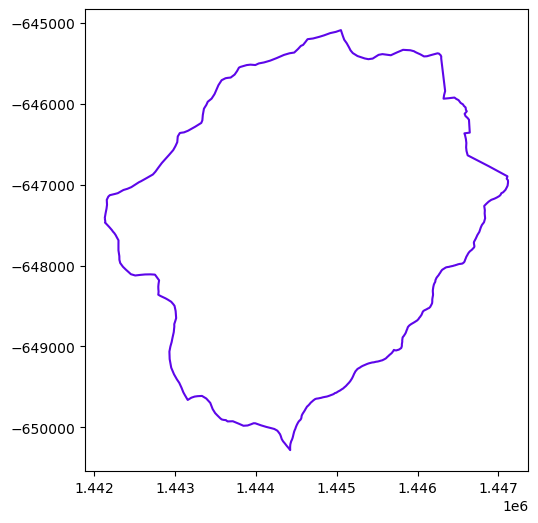

In [59]:
# Construct and plot the WW object used for storing watersheds
watershed = watershed_workflow.split_hucs.SplitHUCs(coweeta)
watershed.plot()

✏️ Let's see what constitutes `watershed` object.

In [60]:
# methods and attributes
for f in dir(watershed):
   print(f)

__class__
__delattr__
__dict__
__dir__
__doc__
__eq__
__format__
__ge__
__getattribute__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__le__
__len__
__lt__
__module__
__ne__
__new__
__reduce__
__reduce_ex__
__repr__
__setattr__
__sizeof__
__slotnames__
__str__
__subclasshook__
__weakref__
boundaries
computePolygon
crs
deepcopy
df
explore
explore_linestrings
exterior
exterior_outlet
gons
intersections
linestrings
plot
plotAsLinestrings
polygons
spines
to_crs
to_dataframe
update


In [61]:
# watershed
# watershed.df
# watershed.exterior
list(watershed.linestrings)

[<LINESTRING (1443453.518 -645937.256, 1443489.888 -645881.16, 1443538.048 -6...>]

## the Rivers 

`River` is a tree data structure that organizes stream reaches as nodes, with all node attributes stored in a geopandas DataFrame. Each node can be accessed and queried efficiently using its index.


Geometry of the river network can be loaded from a shapefile, NHD/NHDPlus, or other sources into a **GeoDataFrame** of `reaches`.

In [62]:
# download/collect the river network within that shape's bounds
reaches = sources['hydrography'].getShapesByGeometry(watershed.exterior, crs, out_crs=crs)

2025-09-10 14:10:16,322 - root - INFO: fixing column: catchment
2025-09-10 14:10:16,335 - root - INFO: fixing column: geometry


✏️ Let's look at `reaches`

In [66]:
reaches 
#reaches.iloc[0]
#dict(reaches.iloc[0])
#reaches.iloc[0].geometry


,name,length,catchment_area,stream_order,drainage_area_sqkm,catchment,hydroseq,uphydroseq,dnhydroseq,divergence,geometry,ID,nhdplusid
0,Mill Branch,0.871359,0.3906,1,0.3906,"POLYGON ((1443756.451 -647559.338, 1443882.399...",25000400251500,0,25000400134610,0,"LINESTRING (1443952.368 -647344.594, 1443957.5...",25000400328912,25000400328912
1,Pinnacle Branch,1.035240,1.1435,1,1.1435,"POLYGON ((1442773.433 -648163.006, 1442783.122...",25000400248911,0,25000400120017,0,"LINESTRING (1442584.588 -647318.611, 1442589.5...",25000400334861,25000400334861
2,Coweeta Creek,2.824770,2.9332,3,18.7276,"POLYGON ((1447100.427 -646898.806, 1447110.115...",25000400060844,25000400064695,25000400055396,0,"LINESTRING (1446355.827 -646359.856, 1446361.8...",25000400358462,25000400358462
3,None,0.818986,0.5894,1,0.5894,"POLYGON ((1444654.108 -649719.175, 1444683.174...",25000400227570,0,25000400129735,0,"LINESTRING (1444882.468 -649129.518, 1444879.9...",25000400383591,25000400383591
4,Camprock Branch,1.290706,0.9075,1,0.9075,"POLYGON ((1444992.261 -646497.854, 1444991.649...",25000400226762,0,25000400082835,0,"LINESTRING (1443993.483 -645890.897, 1443999.3...",25000400385380,25000400385380
5,Cunningham Creek,0.775186,0.4009,2,1.7986,"POLYGON ((1444705.596 -647034.578, 1444744.349...",25000400134610,25000400210321,25000400070770,0,"LINESTRING (1444716.204 -647032.097, 1444718.9...",25000400397871,25000400397871
6,Shope Fork,1.173187,0.9912,1,0.9912,"POLYGON ((1442990.031 -648808.825, 1442999.72 ...",25000400211263,0,25000400120017,0,"LINESTRING (1443401.296 -648268.526, 1443404.4...",25000400421101,25000400421101
7,Cunningham Creek,1.361684,1.0071,1,1.0071,"POLYGON ((1443430.607 -648395.581, 1443440.296...",25000400210321,0,25000400134610,0,"LINESTRING (1444074.44 -648016.28, 1444079.661...",25000400423293,25000400423293
8,None,1.044630,0.7605,1,0.7605,"POLYGON ((1445003.578 -646219.411, 1445022.954...",25000400210191,0,25000400064695,0,"LINESTRING (1444874.58 -645383.562, 1444877.93...",25000400423603,25000400423603
9,Shope Fork,0.987406,0.5574,2,3.8699,"MULTIPOLYGON (((1443973.573 -647151.862, 14439...",25000400100976,25000400120017,25000400082835,0,"LINESTRING (1444135.674 -646749.93, 1444143.93...",25000400427412,25000400427412


✏️  Rivers are constructed using a collection of reaches using one of the following methods:

1) `geometry` looks at coincident coordinates. This is needed when working with non-NHD data.
2) `hydroseq` is valid only for NHDPlus data. This method uses the NHDPlus VAA tables Hydrologic Sequence. 
3) `native` reads a natively dumped list of rivers.

In [67]:
rivers = watershed_workflow.river_tree.createRivers(reaches, method='hydroseq') # other method: 'geometry'
watershed_orig, rivers_orig = watershed, rivers

✏️ Reducing Rivers

The `reduceRivers` method provides tools to simplify river networks before modeling.  
It can remove small rivers, prune reaches by contributing area, or filter out diversions and braided divergences.  
Use this when you need a cleaner, more computationally efficient network while retaining the main flow paths.  


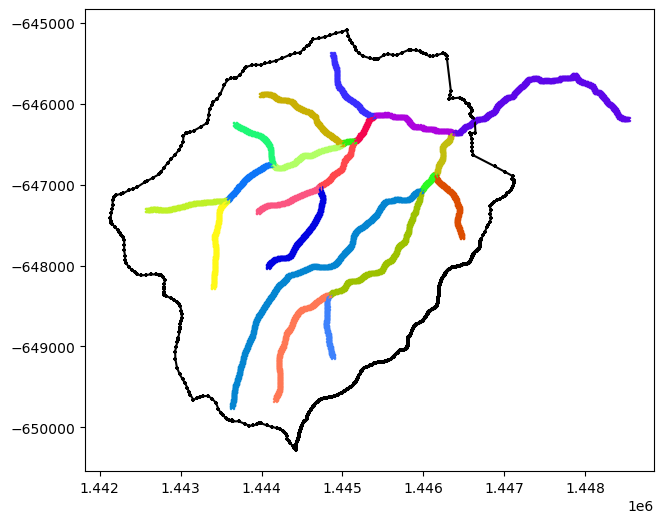

In [68]:
# plot the rivers and watershed
def plot(ws, rivs, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1)
    ws.plot(color='k', marker='+', markersize=10, ax=ax)
    for river in rivs:
        river.plot(marker='x', markersize=10, ax=ax)

plot(watershed, rivers)

### ✏️  Training Cells: River Tree Features -----

This class expects a **GeoPandas GeoDataFrame**, where each row corresponds to one reach (node).  
Only **`index`** and **`geometry`** are required; additional attributes can be included as needed.  

---

| Attributes    | Type                  | Description                                                                 |
|--------------|-----------------------|-----------------------------------------------------------------------------|
| **index**    | (GeoDataFrame index)  | Unique identifier for each reach. Must be the GeoDataFrame’s index (not a column). |
| **geometry** | `shapely.LineString`  | The centerline of the reach. Each node is represented by one `LineString`.   |

**Common Example Properties:**

| Property       | Type                | Description                                                                 |
|----------------|---------------------|-----------------------------------------------------------------------------|
| **catchment**  | `shapely.Polygon`   | Local contributing area polygon for this reach.                             |
| **area**       | `float` (m²)        | Area of the local catchment. If missing but `catchment` exists, it can be derived. |
| **stream_order** | `int`             | Stream order of the reach (e.g., Strahler or Shreve order, depending on source hydrography). |



In [72]:
river = rivers[0]
river.df # dataframe
river.index # unique identifier
river.linestring # geometry
river.properties # properties

name                                                      Coweeta Creek
length                                                          2.82477
catchment_area                                                   2.9332
stream_order                                                          3
drainage_area_sqkm                                              18.7276
catchment             POLYGON ((1447100.42704482 -646898.806463681, ...
hydroseq                                                 25000400060844
uphydroseq                                               25000400064695
dnhydroseq                                               25000400055396
divergence                                                            0
geometry              LINESTRING (1446355.8270394902 -646359.8560352...
ID                                                       25000400358462
nhdplusid                                                25000400358462
Name: 0, dtype: object

<b>Nodes</b> </br>
A `River` is a composed of nodes. A single node in the River is also a `River` object, representing one reach and its upstream children.

In [73]:
# Traversing tree
# Basic tree traversal uses the `preOrder()` method, which is a depth-first traversal of the tree.
nodes = [node for node in river.preOrder()]
for node in nodes:
    print(node.properties['ID'])

25000400358462
25000400528468
25000400488802
25000400456886
25000400431661
25000400383591
25000400458981
25000400492703
25000400461115
25000400509565
25000400397871
25000400423293
25000400328912
25000400463186
25000400427412
25000400499020
25000400421101
25000400334861
25000400492705
25000400385380
25000400423603


Example tree:

        A
       / \
      B   C
     / \   \
    D   E   F

Depth First Preorder Traversal (Root → Left → Right)
A → B → D → E → C → F


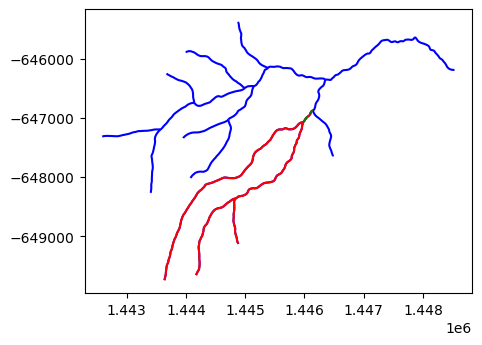

In [82]:
fig, ax = plt.subplots(figsize=(5, 5))
river.plot(ax=ax, color='b')
node = nodes[3]
node.plot(ax=ax, color='r', linestyle='-')  ##### CHANGE TO 2, 3, .. and march up the river #####
ax.plot(*node.linestring.xy, color='g', linestyle='--')
ax.set_aspect('equal')


Children

number of children: 2


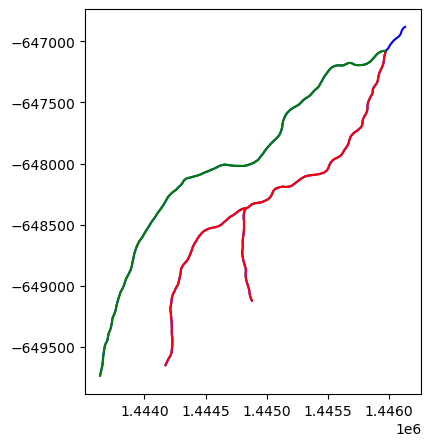

In [84]:
node = nodes[3]
print('number of children:', len(node.children))

fig, ax = plt.subplots(figsize=(5, 5))
node.plot(ax=ax, color='b', linestyle='-')
node.children[0].plot(ax=ax, color='r', linestyle='-')
node.children[1].plot(ax=ax, color='g', linestyle='-')
# ax.plot(*node.linestring.xy, color='g', linestyle='--')
ax.set_aspect('equal')


Siblings

<Axes: >

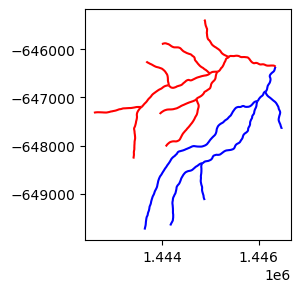

In [86]:
# we can access siblings 
node = nodes[1]

siblings = list(node.siblings); print(siblings)
fig, ax = plt.subplots(1, 1, figsize=(3,3))
node.plot(color='b', ax=ax)
siblings[0].plot(ax=ax, color='r')



Parent

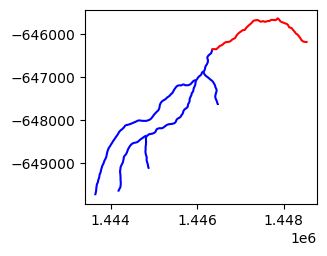

In [87]:
# we can access parent node
parent = node.parent
fig, ax = plt.subplots(1, 1, figsize=(3,3))
node.plot(color='b', ax=ax)
ax.plot(*parent.linestring.xy, color='r', linestyle='-')

In [88]:
# geometry methods 
node.linestring.length

rivers[0].linestring.length

2728.568946878084

### ------------------------

In [89]:
# keeping the originals for plotting comparisons
def createCopy(watershed, rivers):
    """To compare before/after, we often want to create copies.  Note in real workflows most things are done in-place without copies."""
    return watershed.deepcopy(), [r.deepcopy() for r in rivers]
    

 ✏️ Refinement controls

The discretization of watershed boundary and river tree constrains the triangulation. 

<img src="./notebook_images/mesh_concept.png" alt="adaptive refinement" width="15%"/>


In [90]:
refine_d0 = 200
refine_d1 = 600

refine_L0 = 125
refine_L1 = 300

<img src='./notebook_images/adaptive_refinement.png' width='300' height='225' alt='adaptive refinement' align='center' /> </br>

The watershed workflow provides multiple strategies for resampling river networks, allowing users to control the resolution and detail of river representations based on different criteria and requirements.

• **Fixed Length**: Uses a single uniform target segment length across all river reaches for consistent resolution

• **Property-Based**: Reads target lengths from each reach's stored properties, enabling different resolutions for different river segments

• **Function-Driven**: Employs custom functions to dynamically compute target lengths with min/max bounds, offering maximum flexibility for complex logic

• **Distance-Adaptive**: Varies resolution based on proximity to reference shapes, providing finer detail near important features and coarser detail elsewhere

| Parameter                | Type              | Default | Description |
|---------------------------|-------------------|---------|-------------|
| `hucs`                   | `SplitHUCs`       | —       | HUC and river shapes to simplify. |
| `rivers`                 | `List[River]`     | —       | River objects to simplify (modified in place). |
| `reach_segment_target_length` | `float`      | —       | Target length for reach segments. |
| `huc_segment_target_length`   | `Optional[float]` | None  | Target length for HUC segments. |
| `river_close_distance`    | `float`          | 100.0   | Distance threshold for “close” rivers. |
| `river_far_distance`      | `float`          | 500.0   | Distance threshold for “far” rivers. |
| `resample_by_reach_property` | `bool`        | False   | Resample by reach property instead of fixed length. |
| `min_angle`               | `float`          | 20      | Minimum angle for simplification (degrees). |
| `junction_min_angle`      | `float`          | 20      | Minimum angle enforced at junctions (degrees). |
| `snap_triple_junctions_tol` | `Optional[float]` | None | Tolerance for snapping triple junctions. |
| `plot_diagnostics`        | `bool`           | False   | Plot diagnostics during simplification. |
| `keep_points`             | `bool`           | False   | Keep original points for reference. |


In [91]:
watershed, rivers = createCopy(watershed_orig, rivers_orig)

# simplifying -- this sets the discrete length scale of both the watershed boundary and the rivers
watershed_workflow.simplify(watershed, rivers, refine_L0, refine_L1, refine_d0, refine_d1)

# simplify may remove reaches from the rivers object
# -- this call removes any reaches from the dataframe as well, signaling we are all done removing reaches
#
# ETC: NOTE -- can this be moved into the simplify call?
for river in rivers:
    river.resetDataFrame()

# Now that the river network is set, find the watershed boundary outlets
for river in rivers:
    watershed_workflow.hydrography.findOutletsByCrossings(watershed, river)

2025-09-10 14:22:57,573 - root - INFO: 
2025-09-10 14:22:57,574 - root - INFO: Simplifying
2025-09-10 14:22:57,575 - root - INFO: ------------------------------
2025-09-10 14:22:57,577 - root - INFO: +proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 +x_0=0 +y_0=0 +ellps=WGS84 +units=m +no_defs +type=crs
2025-09-10 14:22:57,578 - root - INFO: Presimplify to remove colinear, coincident points.
2025-09-10 14:22:57,582 - root - INFO: +proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 +x_0=0 +y_0=0 +ellps=WGS84 +units=m +no_defs +type=crs
2025-09-10 14:22:57,583 - root - INFO: Pruning leaf reaches < 125
2025-09-10 14:22:57,584 - root - INFO: +proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 +x_0=0 +y_0=0 +ellps=WGS84 +units=m +no_defs +type=crs
2025-09-10 14:22:57,585 - root - INFO: Merging internal reaches < 125
2025-09-10 14:22:57,586 - root - INFO: +proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 +x_0=0 +y_0=0 +ellps=WGS84 +units=m +no_defs +type=crs
2025-09-10 14:22:57,5

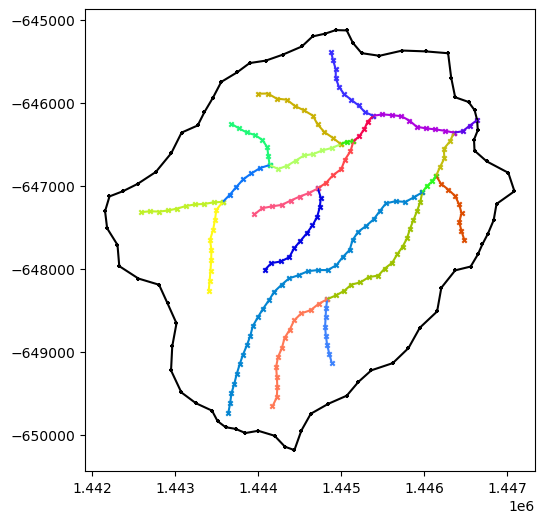

In [92]:
plot(watershed, rivers)

In [93]:
# this generates a zoomable map, showing different reaches and watersheds, 
# with discrete points.  Problem areas are clickable to get IDs for manual
# modifications.
m = watershed.explore(marker=False)
for river in rivers_orig:
    m = river.explore(m=m, column=None, color='black', name=river['name']+' raw', marker=False)
for river in rivers:
    m = river.explore(m=m)
    
m = watershed_workflow.makeMap(m)
m

## Mesh Geometry

Now we create stream-aligned mesh conforming to the above discretization of river tree and watershed boundary. River width can be provided either using a dictionary stream-order:width, or width can be assigned as a property for each node, which can be read on the fly while assigning width of quad elements in the river mesh. 

2025-09-10 14:24:51,593 - root - INFO: 
2025-09-10 14:24:51,594 - root - INFO: Stream-aligned Meshing
2025-09-10 14:24:51,594 - root - INFO: ------------------------------
2025-09-10 14:24:51,595 - root - INFO: Creating stream-aligned mesh...
2025-09-10 14:24:51,626 - root - INFO: Adjusting HUC to match reaches at outlet
2025-09-10 14:24:51,640 - root - INFO: 
2025-09-10 14:24:51,641 - root - INFO: Triangulation
2025-09-10 14:24:51,641 - root - INFO: ------------------------------
2025-09-10 14:24:51,643 - root - INFO: Triangulating...
2025-09-10 14:24:51,645 - root - INFO:    443 points and 444 facets
2025-09-10 14:24:51,645 - root - INFO:  checking graph consistency
2025-09-10 14:24:51,645 - root - INFO:  tolerance is set to 1.0
2025-09-10 14:24:51,648 - root - INFO:  building graph data structures
2025-09-10 14:24:51,651 - root - INFO:  triangle.build...
2025-09-10 14:24:51,934 - root - INFO:   ...built: 1427 mesh points and 2409 triangles
2025-09-10 14:24:51,935 - root - INFO: Plot

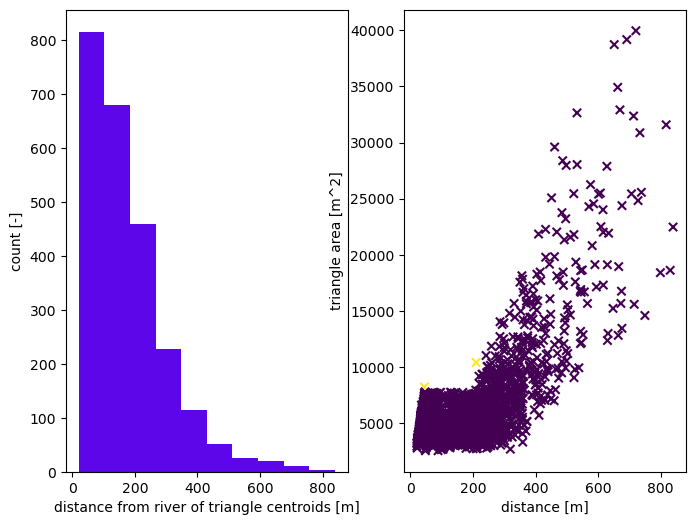

In [94]:
# Refine triangles if they get too acute
min_angle = 32 # degrees

# width of reach by stream order (order:width)
widths = dict({1:8,2:12,3:16})

# create the mesh
m2, areas, dists = watershed_workflow.tessalateRiverAligned(watershed, rivers, 
                                                            river_width=widths,
                                                            refine_min_angle=min_angle,
                                                            refine_distance=[refine_d0, refine_A0, refine_d1, refine_A1],
                                                            diagnostics=True)

2025-09-10 14:26:22,688 - matplotlib.axes._base - WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
2025-09-10 14:26:22,703 - matplotlib.axes._base - WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


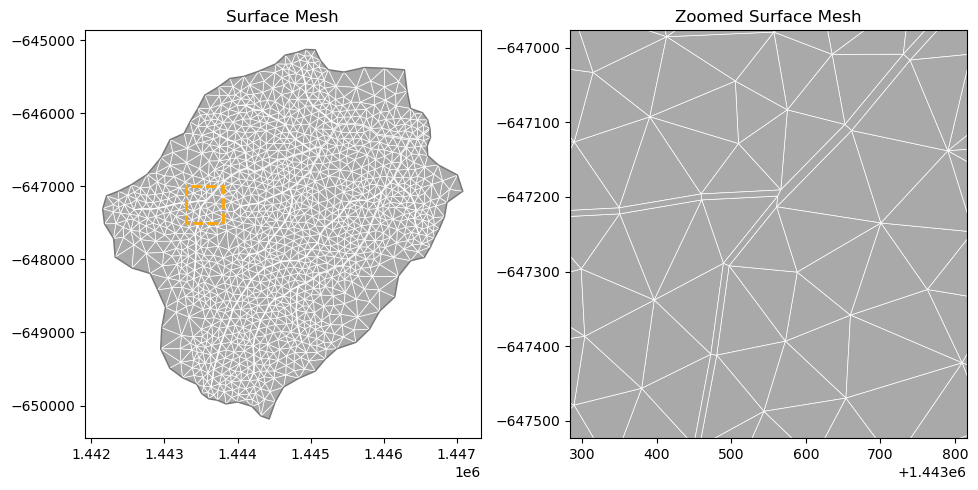

In [95]:
from shapely.geometry import box
from matplotlib.patches import Polygon as mplPolygon
# plotting surface mesh wireframe with two subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot the main mesh without a color bar in the first subplot
mp = m2.plot(facecolor='darkgray', edgecolor='w', ax=axs[0], linewidth=0.5, colorbar=False)
axs[0].set_title('Surface Mesh')
axs[0].set_aspect('equal', 'datalim')
watershed.plot(ax=axs[0], alpha=0.5, color='k', linewidth=1)

# Plot the zoom-in box for reference on the left plot in dashed yellow
zoom_box = box(1.4433e6, -647500, 1.4438e6, -647000)
zoom_box_patch = mplPolygon(list(zoom_box.exterior.coords), closed=True, edgecolor='orange', linewidth=2, linestyle='--', facecolor='none')
axs[0].add_patch(zoom_box_patch)

# Plot the zoomed-in mesh in the second subplot
mp_zoom = m2.plot(facecolor='darkgray', edgecolor='w', ax=axs[1], linewidth=0.5, colorbar=False)
axs[1].set_title('Zoomed Surface Mesh')
axs[1].set_aspect('equal', 'datalim')
watershed.plot(ax=axs[1], alpha=0.5, color='k', linewidth=1)

# Set the limits to zoom in
xlim = (1.4433e6, 1.4438e6)
ylim = (-647500, -647000)
axs[1].set_xlim(xlim)
axs[1].set_ylim(ylim)

plt.tight_layout()
plt.show()


### ✏️ Training Cells: Tessellation Options --------

<b> Internal Boundaries and Refinement </b>

In [96]:
refine_d0 = 200
refine_d1 = 600

refine_A0 = refine_L0**2 / 2
refine_A1 = refine_L1**2 / 2

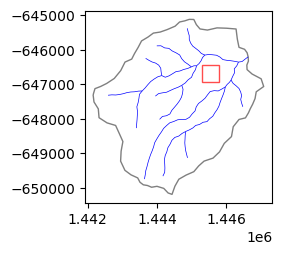

In [97]:
# Create a box shape using shapely's box function
box_shape = box(1445315, -646934, 1445805, -646458)

# Set up the plot
fig, ax = plt.subplots(figsize=(2.5,2.5))

# Plot the box shape using ax.add_patch
box_patch = mplPolygon(list(box_shape.exterior.coords), closed=True, edgecolor='r', linewidth=1, alpha=0.7, facecolor='none')
ax.add_patch(box_patch)

# Plot the watershed and rivers
watershed.plot(ax=ax, alpha=0.5, color='k', linewidth=1)
rivers[0].plot(ax=ax, color='b', linewidth=0.5)

# Display the plot
plt.show()

2025-09-10 14:29:56,455 - root - INFO: 
2025-09-10 14:29:56,456 - root - INFO: Stream-aligned Meshing
2025-09-10 14:29:56,457 - root - INFO: ------------------------------
2025-09-10 14:29:56,457 - root - INFO: Creating stream-aligned mesh...
2025-09-10 14:29:56,501 - root - INFO: 
2025-09-10 14:29:56,502 - root - INFO: Triangulation
2025-09-10 14:29:56,502 - root - INFO: ------------------------------
2025-09-10 14:29:56,503 - root - INFO: Triangulating...
2025-09-10 14:29:56,505 - root - INFO:    443 points and 444 facets
2025-09-10 14:29:56,505 - root - INFO:  checking graph consistency
2025-09-10 14:29:56,505 - root - INFO:  tolerance is set to 1.0
2025-09-10 14:29:56,508 - root - INFO:  building graph data structures
2025-09-10 14:29:56,510 - root - INFO:  triangle.build...
2025-09-10 14:29:57,237 - root - INFO:   ...built: 1979 mesh points and 3513 triangles
2025-09-10 14:29:57,238 - root - INFO: Plotting triangulation diagnostics
2025-09-10 14:29:57,451 - root - INFO:   min area

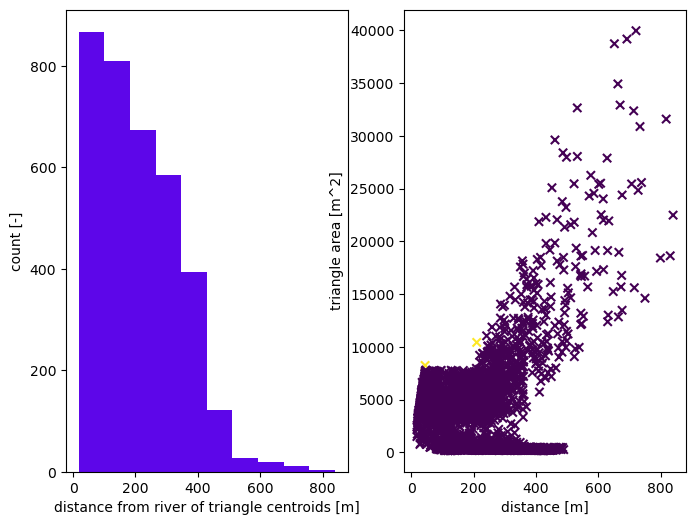

In [103]:
# Refine triangles if they get too acute
min_angle = 32 # degrees

# width of reach by stream order (order:width)
widths = dict({1:8,2:12,3:16})

# create the mesh
m2, areas, dists = watershed_workflow.tessalateRiverAligned(watershed, rivers, 
                                                            river_width=widths,
                                                            refine_min_angle=min_angle,
                                                            refine_polygons = [[box_shape], 500],
                                                            #internal_boundaries = [box_shape],
                                                            refine_distance=[refine_d0, refine_A0, refine_d1, refine_A1],
                                                            diagnostics=True)

2025-09-10 14:29:57,899 - matplotlib.axes._base - WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
2025-09-10 14:29:57,915 - matplotlib.axes._base - WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


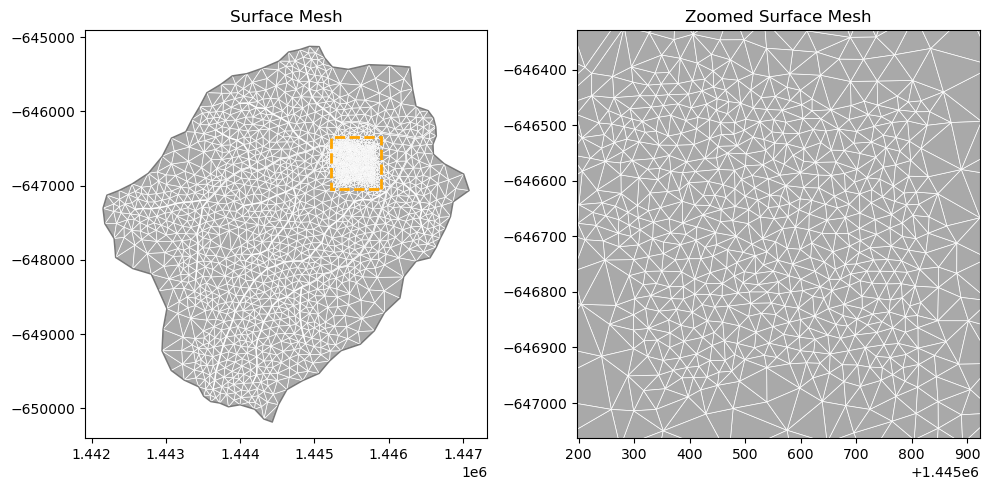

In [104]:
# plotting surface mesh wireframe with two subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot the main mesh without a color bar in the first subplot
mp = m2.plot(facecolor='darkgray', edgecolor='w', ax=axs[0], linewidth=0.5, colorbar=False)
axs[0].set_title('Surface Mesh')
axs[0].set_aspect('equal', 'datalim')
watershed.plot(ax=axs[0], alpha=0.5, color='k', linewidth=1)

#rivers[0].plot(ax=axs[0], color='red', linewidth=0.5)

# Plot the zoomed-in mesh in the second subplot
mp_zoom = m2.plot(facecolor='darkgray', edgecolor='w', ax=axs[1], linewidth=0.5, colorbar=False)
axs[1].set_title('Zoomed Surface Mesh')
axs[1].set_aspect('equal', 'datalim')
watershed.plot(ax=axs[1], alpha=0.5, color='k', linewidth=1)

# Set the limits to zoom in
xlim = (1445224.0, 1445896.0)
ylim = (-647047.2, -646344.8)
axs[1].set_xlim(xlim)
axs[1].set_ylim(ylim)

# Create a zoom box and add it to the plot
zoom_box = box(xlim[0], ylim[0], xlim[1], ylim[1])
zoom_box_patch = mplPolygon(list(zoom_box.exterior.coords), closed=True, edgecolor='orange', linewidth=2, linestyle='--', facecolor='none')
axs[0].add_patch(zoom_box_patch)

plt.tight_layout()
plt.show()


### ----------------------------

In [109]:
# get a raster for the elevation map, based on 3DEP
dem = sources['DEM'].getDataset(watershed.exterior.buffer(100), watershed.crs)['dem']

# provide surface mesh elevations
watershed_workflow.elevate(m2, dem)

2025-09-10 14:30:29,903 - root - INFO: Incoming shape area = 0.0017762297239054818
2025-09-10 14:30:29,905 - root - INFO: ... buffering incoming shape by = 0.00108
2025-09-10 14:30:29,909 - root - INFO: ... buffered shape area = 0.001965147891366844
2025-09-10 14:30:29,910 - root - INFO: Getting DEM with map of area = 0.001965147891366844


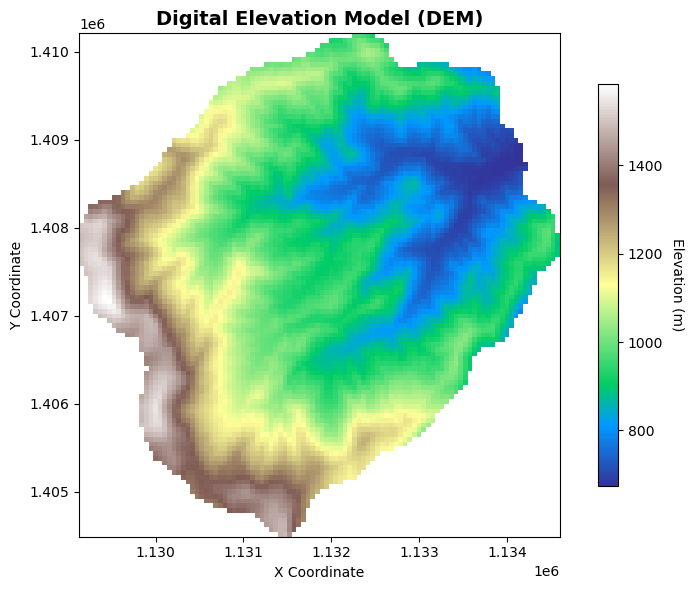

In [110]:
# Plot the DEM raster
fig, ax = plt.subplots()

# Plot the DEM data
im = dem.plot(ax=ax, cmap='terrain', add_colorbar=False)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Elevation (m)', rotation=270, labelpad=15)

# Add title and labels
ax.set_title('Digital Elevation Model (DEM)', fontsize=14, fontweight='bold')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')

# Set equal aspect ratio
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In the pit-filling algorithm, we want to make sure that river corridor is not filled up. Hence we exclude river corridor cells from the pit-filling algorithm.

In [111]:
# hydrologically condition the mesh, removing pits
river_mask=np.zeros((len(m2.conn)))
for i, elem in enumerate(m2.conn):
    if not len(elem)==3:
        river_mask[i]=1     
watershed_workflow.condition.fillPitsDual(m2, is_waterbody=river_mask)

There are a range of options to condition river corridor mesh. We hydrologically condition the river mesh, ensuring unimpeded water flow in river corridors by globally adjusting flowlines to rectify artificial obstructions from inconsistent DEM elevations or misalignments. Please read the documentation for more information


In [112]:
# conditioning river mesh
#
# adding elevations to the river tree for stream bed conditioning
watershed_workflow.condition.setProfileByDEM(rivers, dem)

# conditioning the river mesh using NHD elevations
watershed_workflow.condition.conditionRiverMesh(m2, rivers[0])

2025-09-10 14:31:29,286 - matplotlib.axes._base - WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


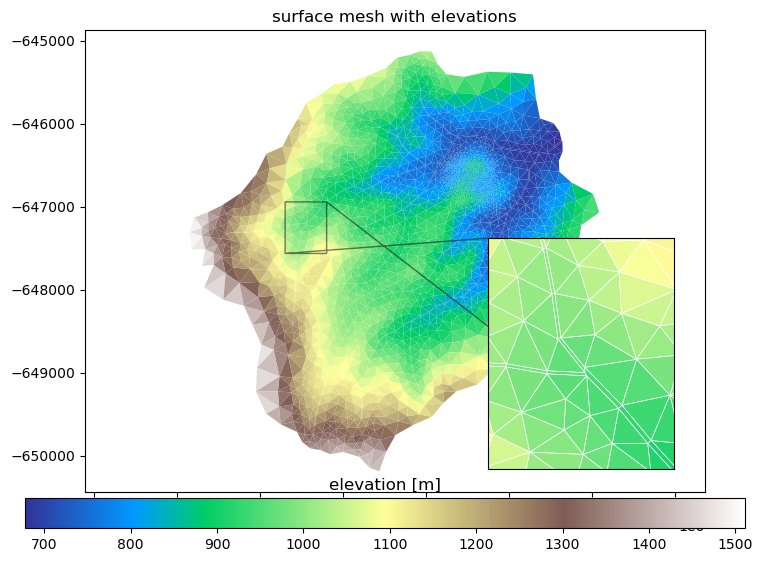

In [113]:
# plotting surface mesh with elevations
fig, ax = plt.subplots()
ax2 = ax.inset_axes([0.65,0.05,0.3,0.5])
cbax = fig.add_axes([0.05,0.05,0.9,0.05])

mp = m2.plot(facecolors='elevation', edgecolors=None, ax=ax, linewidth=0.5, colorbar=False)
cbar = fig.colorbar(mp, orientation="horizontal", cax=cbax)
ax.set_title('surface mesh with elevations')
ax.set_aspect('equal', 'datalim')

mp2 = m2.plot(facecolors='elevation', edgecolors='white', ax=ax2, colorbar=False)
ax2.set_aspect('equal', 'datalim')

xlim = (1.4433e6, 1.4438e6)
ylim = (-647000, -647500)

ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ax2.set_xticks([])
ax2.set_yticks([])

ax.indicate_inset_zoom(ax2, edgecolor='k')

cbar.ax.set_title('elevation [m]')

plt.show()


## River/Stream-specific LabeledSets

✏️  **Labeled Sets**

A **labeled set** is a way to group subsets of a mesh or geometry and tag them with meaningful names.  
They provide a bridge between the abstract mesh elements (faces, cells) and the physical or conceptual features of the watershed.  

Key ideas  
- **Definition**: A labeled set is simply a *collection of mesh entities* (e.g., all faces along the watershed outlet) that share a common label.  
- **Purpose**: Labels make it easy to refer to important regions without needing to remember low-level indices (GIDs).  
- **Examples**:  
  - `"outlet"` → all cells or faces that form the watershed outlet  
  - `"river_corridor"` → elements along the river channel  
  - `"boundary_top"` → outer boundary elements exposed to atmosphere  

Why they matter  
- They enable **boundary conditions** to be applied cleanly (e.g., rainfall on `"boundary_top"`, discharge at `"outlet"`).  
- They support **parameter specification** by grouping mesh regions under a label  (e.g., prescribing Manning’s roughness coefficient along `"river_corridor"`).   
- They allow for **flexible observations and analysis**: ATS can record values over labeled regions and perform operations like averages or summations on the fly  (e.g., recording streamflow at the `"downstream_region"`). 



<img src='./notebook_images/labeled_sets.png' width='300' height='300' alt='adaptive refinement' align='center' /> </br>

In [114]:
# add labeled sets for subcatchments and outlets
watershed_workflow.regions.addWatershedAndOutletRegions(m2, watershed, outlet_width=250, exterior_outlet=True)

# add labeled sets for river corridor cells
watershed_workflow.regions.addRiverCorridorRegions(m2, rivers)

# add labeled sets for river corridor cells by order
watershed_workflow.regions.addStreamOrderRegions(m2, rivers)

2025-09-10 14:32:10,405 - root - INFO: Adding regions for 1 polygons


In [115]:
for ls in m2.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

10000 : CELL : 3697 : "Coweeta Hydrologic Lab"
10001 : CELL : 3697 : "Coweeta Hydrologic Lab surface"
10002 : FACE : 76 : "Coweeta Hydrologic Lab boundary"
10003 : FACE : 5 : "Coweeta Hydrologic Lab outlet"
10004 : FACE : 5 : "surface domain outlet"
10005 : CELL : 184 : "river corridor 0 surface"
10006 : CELL : 16 : "stream order 3"
10007 : CELL : 46 : "stream order 2"
10008 : CELL : 122 : "stream order 1"


✏️  **Labeled Sets usage input file**
# # 
# <img src='./notebook_images/surface_domain_outlet_region.png' width='35%'  alt='adaptive refinement' align='center' /> </br>
# 
# <img src='./notebook_images/surface_domain_outlet_bc.png' width='35%'  alt='adaptive refinement' align='center' /> </br>
# 
# <img src='./notebook_images/surface_domain_outlet_observation.png' width='35%' alt='adaptive refinement' align='center' /> </br>

<b> This concludes part 1 of the workflow, in which spatial discretization of the watershed and river network is performed, and surface mesh geometry is created. </b>

In [116]:
import pickle
import os

intermediate_dir = './intermediate_files/'

# Ensure the intermediate directory exists
os.makedirs(intermediate_dir, exist_ok=True)

# Save m2 and watershed objects using pickle
with open(os.path.join(intermediate_dir, 'm2.pkl'), 'wb') as f:
    pickle.dump(m2, f)

with open(os.path.join(intermediate_dir, 'watershed.pkl'), 'wb') as f:
    pickle.dump(watershed, f)

# Concatenate river dataframes and save as parquet
river_df = pd.concat([river.to_dataframe() for river in rivers])
river_df.to_parquet(os.path.join(intermediate_dir, 'rivers.parquet'))

print("Intermediate files saved successfully.")

Intermediate files saved successfully.
